# Final Project  
Nama: Delon Tantri Wijaya  
NIM: 2802397823

Link YT: https://youtu.be/2IelVS_tMAM  
Link Streamlit AWS: http://13.220.49.69:8501/ (ternyata ip addressnya berubah terus bu, jadi ada kemungkinan linkya udh ngga bisa)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## Load Dataset

In [2]:
df = pd.read_csv('data_A.csv')
print(df.shape)
df.head()

(25000, 29)


,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0xa658,CUS_0x936d,March,Alistair Barrs,8466,703-48-3482,_______,100433.58,8074.465000,...,Good,1023.93,33.471395,20 Years and 5 Months,No,100.163466,758.0704866746678,Low_spent_Medium_value_payments,229.21254743638283,Standard
1,1,0x6739,CUS_0x9a29,August,Phila,25,339-28-0072,Developer,33119.82,3024.985000,...,Bad,2545.0,33.810567,14 Years and 8 Months,Yes,111.422702,NaN,Low_spent_Small_value_payments,370.6074980582689,Poor
2,2,0xdcf5,CUS_0x12a9,April,Driverb,44,583-20-9758,_______,44822.21,3555.184167,...,Good,730.64,31.145739,23 Years and 10 Months,NM,135.044286,256.4742969677053,Low_spent_Medium_value_payments,243.99983412342044,Standard
3,3,0x14453,CUS_0x3bad,June,Prasadc,29,510-25-2095,Musician,142081.48,11771.123333,...,Standard,932.32,28.409526,27 Years and 0 Months,No,180.616478,423.96126196668365,Low_spent_Small_value_payments,862.534593039876,Standard
4,4,0x1198e,CUS_0xa3e1,January,Poornimai,45,943-92-4350,Scientist,19267.27_,1374.605833,...,Bad,3777.55,28.373426,10 Years and 3 Months,Yes,78.954825,133.56850235207634,Low_spent_Small_value_payments,214.93725572483646,Poor


## Data Understanding

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22440 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21417 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,25000.0,NaN,NaN,NaN,12499.5,7217.022701,0.0,6249.75,12499.5,18749.25,24999.0
ID,25000,25000,0xa658,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,25000,11252,CUS_0x6b8,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month,25000,8,April,3173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,22440,9027,Strupczewskid,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,25000,520,38,740,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SSN,25000,11037,#F%$D@*&8,1456,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,25000,16,_______,1770,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Annual_Income,25000,12889,72524.2,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Monthly_Inhand_Salary,21417.0,NaN,NaN,NaN,4215.671131,3187.623134,303.645417,1634.720833,3111.4375,5986.6475,15167.18


## Missing Value & Target Analysis

In [5]:
display(pd.DataFrame({
    'Missing': df.isnull().sum(),
}).sort_values('Missing', ascending=False).head(20))

print("Duplicate Rows:", df.duplicated().sum())

,Missing
Monthly_Inhand_Salary,3583
Type_of_Loan,2828
Name,2560
Credit_History_Age,2249
Num_of_Delayed_Payment,1733
Amount_invested_monthly,1164
Num_Credit_Inquiries,506
Monthly_Balance,289
Payment_Behaviour,0
Total_EMI_per_month,0


Duplicate Rows: 0


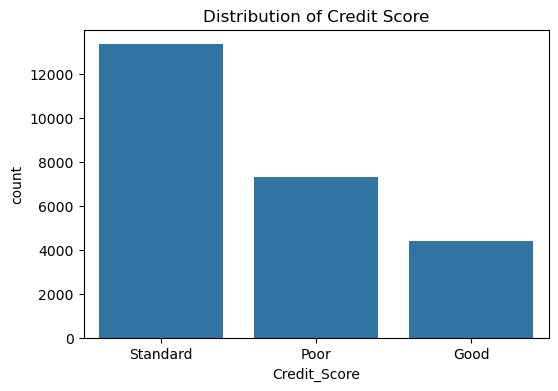

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Credit_Score')
plt.title('Distribution of Credit Score')
plt.show()

## Temuan Eksplorasi Data (Exploratory Data Analysis)
### 1. Struktur Dataset
Dataset Credit Score Classification terdiri dari berbagai atribut yang menggambarkan kondisi finansial dan riwayat kredit nasabah, seperti umur, pendapatan tahunan, jumlah rekening bank, jumlah kartu kredit, jumlah pinjaman, tingkat bunga, riwayat pembayaran, serta kategori Credit Score sebagai target klasifikasi.  
Target yang akan di prediksi adalah:  
`Credit_Score`  
dengan tiga kategori:  
Good  
Standard  
Poor  

### 2. Kualitas Data
Hasil eksplorasi menunjukkan bahwa dataset masih mengandung berbagai permasalahan kualitas data, antara lain:  
Missing Values  
Beberapa fitur memiliki nilai kosong atau tidak valid yang harus ditangani sebelum proses pemodelan dilakukan.  
Contoh:  
`Credit_History_Age`  
`Monthly_Inhand_Salary`  
`Changed_Credit_Limit`  
`Payment_of_Min_Amount`  
Untuk mengatasi masalah tersebut dilakukan imputasi:  
Median untuk fitur numerik.  
Modus untuk fitur kategorikal.  

Data Tidak Konsisten  
Ditemukan beberapa atribut numerik yang tersimpan sebagai string dan mengandung karakter tambahan.  
Contoh:  
`Annual_Income`  
`Outstanding_Debt`  
`Num_of_Delayed_Payment`  
`Changed_Credit_Limit`  
Oleh karena itu dilakukan proses pembersihan karakter non-numerik dan konversi ke tipe data numerik.  

### 3. Distribusi Target
Visualisasi distribusi Credit Score menunjukkan bahwa jumlah data pada masing-masing kelas tidak sepenuhnya seimbang.  
Secara umum:  
Kelas Standard memiliki jumlah data terbesar.  
Kelas Good memiliki jumlah data sedang.  
Kelas Poor memiliki jumlah data paling sedikit.  
Ketidakseimbangan ini menjadi alasan penggunaan metrik:  
Weighted F1 Score  
selain Accuracy untuk mengevaluasi performa model.  

### 4. Analisis Credit History Age
Variabel:  
`Credit_History_Age`  
awalnya berbentuk teks:  
22 Years and 5 Months  
Kemudian dikonversi menjadi satuan bulan:  
269 bulan  
Transformasi ini membuat informasi riwayat kredit lebih mudah diproses oleh algoritma machine learning.  
Hasil eksplorasi menunjukkan bahwa nasabah dengan riwayat kredit yang lebih panjang cenderung memiliki Credit Score yang lebih baik.  

### 5. Analisis Pendapatan dan Hutang
Variabel:  
`Annual_Income`  
`Outstanding_Debt`  
menunjukkan variasi yang cukup besar antar nasabah.  
Ditemukan bahwa:  
Nasabah dengan pendapatan lebih tinggi cenderung memiliki peluang memperoleh Credit Score yang lebih baik.  
Tingkat hutang yang tinggi berpotensi menurunkan kualitas Credit Score.  

### 6. Analisis Keterlambatan Pembayaran
Variabel:  
`Num_of_Delayed_Payment`  
`Delay_from_due_date`  
menunjukkan hubungan yang cukup kuat dengan Credit Score.  
Hasil eksplorasi menunjukkan bahwa semakin sering nasabah terlambat melakukan pembayaran, semakin besar kemungkinan memperoleh kategori:  
Poor  

### 7. Analisis Jumlah Pinjaman dan Kartu Kredit
Variabel:  
`Num_of_Loan`  
`Num_Credit_Card`  
menunjukkan bahwa nasabah dengan jumlah pinjaman yang terlalu banyak cenderung memiliki risiko kredit yang lebih tinggi.  
Sementara itu, jumlah kartu kredit tidak selalu menunjukkan hubungan linear terhadap Credit Score, sehingga diperlukan model machine learning untuk menangkap pola yang lebih kompleks.

### 8. Outlier
Beberapa fitur numerik memiliki nilai ekstrem (outlier), terutama pada:  
`Annual_Income`  
`Outstanding_Debt`  
`Monthly_Balance`  
`Amount_invested_monthly`  
Untuk mengurangi pengaruh nilai ekstrem terhadap model, dilakukan penanganan outlier menggunakan metode:  
Interquartile Range (IQR)  
melalui teknik capping pada batas bawah dan batas atas.  

### 9. Feature Engineering
Beberapa proses feature engineering yang dilakukan:  
Credit History Age  
22 Years and 5 Months -> 269  
  
Payment of Minimum Amount  
Yes -> 1  
No -> 0  

Transformasi ini menghasilkan fitur numerik yang lebih sesuai untuk algoritma klasifikasi.  

### 10. Kesimpulan EDA
Berdasarkan hasil eksplorasi data, ditemukan bahwa kualitas Credit Score dipengaruhi oleh kombinasi beberapa faktor utama, yaitu:  

Riwayat kredit (Credit History Age)  
Pendapatan tahunan (Annual Income)  
Jumlah keterlambatan pembayaran  
Besarnya hutang (Outstanding Debt)  
Jumlah pinjaman yang dimiliki  
Perilaku pembayaran minimum tagihan  

Selain itu, dataset mengandung missing value, data tidak konsisten, dan outlier yang perlu ditangani melalui preprocessing sebelum digunakan dalam proses pemodelan. Setelah seluruh tahap pembersihan dan transformasi data dilakukan, dataset menjadi lebih siap untuk digunakan pada algoritma klasifikasi seperti Logistic Regression dan Random Forest.

## Data Cleaning

In [7]:
data = df.copy()

drop_cols = ['Unnamed: 0', 'ID', 'Customer_ID', 'Name', 'SSN', 'Month', 'Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_Behaviour']
data = data.drop(columns=[c for c in drop_cols if c in data.columns])

numeric_object_cols = ['Age', 'Annual_Income', 'Num_of_Loan', 'Outstanding_Debt', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']

for col in numeric_object_cols:
    if col in data.columns:
        data[col] = data[col].astype(str).str.replace(r'[^0-9\.-]', '', regex=True)
        data[col] = pd.to_numeric(data[col], errors='coerce')

if 'Payment_Behaviour' in data.columns:
    data['Payment_Behaviour'] = data['Payment_Behaviour'].replace(r'[^A-Za-z_]', np.nan, regex=True)

if 'Num_of_Delayed_Payment' in data.columns:
    data['Num_of_Delayed_Payment'] = data['Num_of_Delayed_Payment'].astype(str).str.replace(r'[^0-9]', '', regex=True)
    data['Num_of_Delayed_Payment'] = pd.to_numeric(data['Num_of_Delayed_Payment'], errors='coerce')

replace_map = {'Occupation': '_______', 'Credit_Mix': '_', 'Changed_Credit_Limit': '_', 'Payment_of_Min_Amount': 'NM'}

for col, val in replace_map.items():
    if col in data.columns:
        data[col] = data[col].replace(val, np.nan)

# Ubah menjadi numerik
if 'Changed_Credit_Limit' in data.columns:
    data['Changed_Credit_Limit'] = pd.to_numeric(data['Changed_Credit_Limit'], errors='coerce')

if 'Num_of_Delayed_Payment' in data.columns:
    data['Num_of_Delayed_Payment'] = pd.to_numeric(data['Num_of_Delayed_Payment'], errors='coerce')

for col in data.columns:
    if data[col].dtype in ['float64', 'int64']:
        data[col] = data[col].fillna(data[col].median())
    else:
        data[col] = data[col].fillna(data[col].mode()[0])
        
print(data.shape)

(25000, 19)


In [8]:
num_cols = data.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    median_val = data[col].median()
    data[col] = np.where(data[col] < 0, median_val, data[col])

for col in num_cols:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr

    data[col] = np.where(data[col] < lower, lower, data[col])
    data[col] = np.where(data[col] > upper, upper, data[col])

## Feature Engineering

In [9]:
def convert_credit_history_age(x):
    try:
        years = int(str(x).split()[0])
        months = int(str(x).split()[3])
        return years*12 + months
    except:
        return np.nan

if 'Credit_History_Age' in data.columns:
    data['Credit_History_Age'] = data['Credit_History_Age'].apply(convert_credit_history_age)
    data['Credit_History_Age'] = data['Credit_History_Age'].fillna(
        data['Credit_History_Age'].median()
    )

if 'Payment_of_Min_Amount' in data.columns:
    data['Payment_of_Min_Amount'] = data['Payment_of_Min_Amount'].map({
        'Yes':1,
        'No':0
    }).fillna(0)

data.head()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score
0,67.5,100433.58,8074.465000,1.0,5.0,10.0,2.0,13.0,4.0,12.59,3.0,1023.93,33.471395,245,0,100.163466,521.810573,229.212547,Standard
1,25.0,33119.82,3024.985000,10.0,5.0,32.0,5.0,50.0,18.0,15.79,10.0,2545.00,33.810567,176,1,111.422702,136.362931,370.607498,Poor
2,44.0,44822.21,3555.184167,1.0,4.0,2.0,4.0,14.0,8.0,4.03,0.0,730.64,31.145739,286,1,135.044286,256.474297,243.999834,Standard
3,29.0,142081.48,10825.411562,6.0,6.0,15.0,3.0,29.0,20.0,8.21,4.0,932.32,28.409526,324,0,180.616478,423.961262,759.781487,Standard
4,45.0,19267.27,1374.605833,10.0,8.0,25.0,6.0,33.0,14.0,19.70,6.0,3777.55,28.373426,123,1,78.954825,133.568502,214.937256,Poor


In [10]:
y = LabelEncoder().fit_transform(df['Credit_Score'])

X = data.drop(columns=['Credit_Score'], errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)

(20000, 18) (5000, 18)


## Logistic Regression

In [11]:
print(X_train.dtypes[X_train.dtypes == 'object'])

Series([], dtype: object)


In [12]:
scaler = StandardScaler()

X_train_lr = scaler.fit_transform(X_train)
X_test_lr = scaler.transform(X_test)

lr = LogisticRegression(max_iter=3000)

lr.fit(X_train_lr, y_train)

pred_lr = lr.predict(X_test_lr)

lr_acc = accuracy_score(y_test,pred_lr)
lr_f1 = f1_score(y_test,pred_lr,average='weighted')

print(classification_report(y_test,pred_lr))
print("Accuracy:", lr_acc)
print("F1:", lr_f1)


              precision    recall  f1-score   support

           0       0.58      0.42      0.49       874
           1       0.67      0.52      0.59      1460
           2       0.65      0.79      0.71      2666

    accuracy                           0.65      5000
   macro avg       0.63      0.58      0.59      5000
weighted avg       0.64      0.65      0.64      5000

Accuracy: 0.645
F1: 0.635558492498099


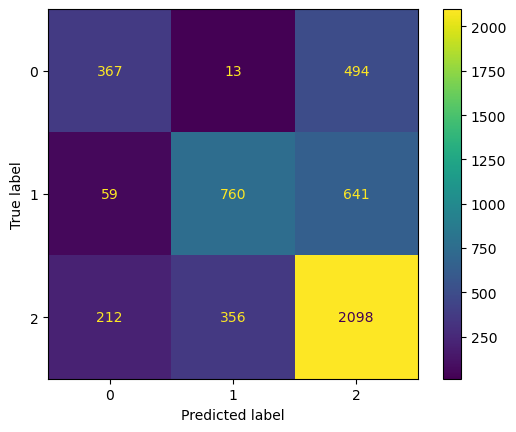

In [13]:
ConfusionMatrixDisplay(
    confusion_matrix(y_test,pred_lr)
).plot()
plt.show()

## Random Forest

In [14]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test,pred_rf)
rf_f1 = f1_score(y_test,pred_rf,average='weighted')

print(classification_report(y_test,pred_rf))
print("Accuracy:", rf_acc)
print("F1:", rf_f1)

              precision    recall  f1-score   support

           0       0.65      0.58      0.61       874
           1       0.76      0.73      0.75      1460
           2       0.75      0.80      0.77      2666

    accuracy                           0.74      5000
   macro avg       0.72      0.70      0.71      5000
weighted avg       0.74      0.74      0.74      5000

Accuracy: 0.7386
F1: 0.7367921022909046


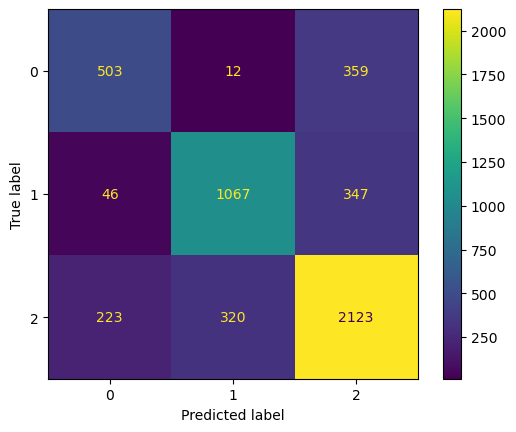

In [15]:
ConfusionMatrixDisplay(
    confusion_matrix(y_test,pred_rf)
).plot()
plt.show()

## Hyperparameter Tuning Random Forest

In [16]:
param_grid = {'n_estimators': [100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5]}

grid = GridSearchCV(rf, param_grid, cv=3, scoring='f1_weighted', n_jobs=-1)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
pred_best = best_rf.predict(X_test)

best_acc = accuracy_score(y_test, pred_best)
best_f1 = f1_score(y_test, pred_best, average='weighted')

print(grid.best_params_)
print("Accuracy:", best_acc)
print("F1:", best_f1)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy: 0.737
F1: 0.7351603537111352


## Cross Validation

In [17]:
cv_lr = cross_val_score(lr, scaler.fit_transform(X), y, cv=5, scoring='f1_weighted').mean()

cv_rf = cross_val_score(best_rf, X, y, cv=5, scoring='f1_weighted').mean()

print("CV Logistic Regression:", cv_lr)
print("CV Random Forest:", cv_rf)

CV Logistic Regression: 0.6249660194558382
CV Random Forest: 0.724626993784787


## Feature Importance

In [18]:
importance = pd.DataFrame({'Feature': X.columns, 'Importance': best_rf.feature_importances_}).sort_values('Importance', ascending=False)

importance.head(10)

,Feature,Importance
11,Outstanding_Debt,0.115992
5,Interest_Rate,0.097746
9,Changed_Credit_Limit,0.069859
7,Delay_from_due_date,0.068744
13,Credit_History_Age,0.062271
12,Credit_Utilization_Ratio,0.054844
10,Num_Credit_Inquiries,0.051079
17,Monthly_Balance,0.050461
16,Amount_invested_monthly,0.050136
8,Num_of_Delayed_Payment,0.050053


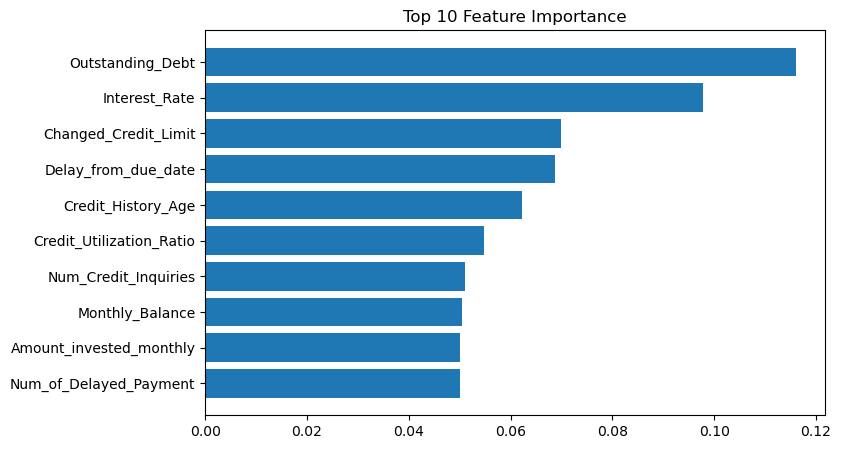

In [19]:
top10 = importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10['Feature'], top10['Importance'])
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importance')
plt.show()

## Model Comparison

In [20]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Random Forest Tuned'],
    'Accuracy': [lr_acc, rf_acc, best_acc],
    'F1 Weighted': [lr_f1, rf_f1, best_f1]
})

results.sort_values('F1 Weighted', ascending=False)

,Model,Accuracy,F1 Weighted
1,Random Forest,0.7386,0.736792
2,Random Forest Tuned,0.7370,0.735160
0,Logistic Regression,0.6450,0.635558


## Kesimpulan

Pada penelitian ini dilakukan pembangunan model machine learning untuk memprediksi **Credit_Score** nasabah berdasarkan data profil keuangan, riwayat kredit, dan perilaku pembayaran. Sebelum proses pemodelan, dilakukan tahap preprocessing yang mencakup pembersihan data inkonsisten, konversi tipe data, penanganan missing value menggunakan median dan modus, perbaikan nilai negatif yang tidak logis, serta penanganan outlier menggunakan metode Interquartile Range (IQR). Selain itu, fitur `Credit_History_Age` dikonversi menjadi total bulan agar lebih mudah diproses oleh model machine learning.

Untuk memperoleh model terbaik, dilakukan eksperimen menggunakan dua algoritma klasifikasi yaitu **Logistic Regression** dan **Random Forest**. Selanjutnya, Random Forest dioptimasi menggunakan **GridSearchCV** untuk mencari kombinasi hyperparameter terbaik berdasarkan nilai weighted F1-score.

Hasil evaluasi menunjukkan bahwa Logistic Regression memperoleh accuracy sebesar **64,5%** dengan weighted F1-score sebesar **63,56%**. Sementara itu, Random Forest menghasilkan accuracy sebesar **73,86%** dan weighted F1-score sebesar **73,68%**. Setelah dilakukan hyperparameter tuning menggunakan GridSearchCV, performa model menurun menjadi accuracy sebesar **73,70%** dan weighted F1-score sebesar **73,52%** dengan parameter terbaik yaitu `n_estimators = 200`, `max_depth = None`, dan `min_samples_split = 2`.

Hasil cross validation juga menunjukkan bahwa Random Forest memiliki kemampuan generalisasi yang lebih baik dibandingkan Logistic Regression. Logistic Regression memperoleh rata-rata weighted F1-score cross validation sebesar **0.6249**, sedangkan Random Forest memperoleh nilai sebesar **0.7246**. Hal ini menunjukkan bahwa Random Forest lebih stabil dalam memprediksi data yang belum pernah dilihat sebelumnya.

Berdasarkan analisis feature importance dari model Random Forest, fitur yang paling berpengaruh dalam menentukan Credit Score adalah **Outstanding_Debt**, **Interest_Rate**, **Changed_Credit_Limit**, **Delay_from_due_date**, dan **Credit_History_Age**. Temuan ini menunjukkan bahwa tingkat hutang, suku bunga kredit, keterlambatan pembayaran, perubahan limit kredit, dan lamanya riwayat kredit merupakan faktor utama yang memengaruhi penilaian kredit nasabah.

Berdasarkan seluruh hasil eksperimen dan evaluasi yang dilakukan, model **Random Forest biasa** dipilih sebagai model terbaik karena menghasilkan nilai accuracy dan weighted F1-score tertinggi dibandingkan model lainnya. Oleh karena itu, model ini dinilai paling sesuai untuk digunakan dalam proses klasifikasi Credit Score pada dataset yang digunakan dalam penelitian ini.
